In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df=pd.read_csv("train.csv")
print("Shape:", df.shape)
display(df.head())
display(df.info())
display(df.describe(include="all"))

Shape: (30000, 24)


,Customer ID,Name,Gender,Age,Income (USD),Income Stability,Profession,Type of Employment,Location,Loan Amount Request (USD),...,Credit Score,No. of Defaults,Has Active Credit Card,Property ID,Property Age,Property Type,Property Location,Co-Applicant,Property Price,Loan Sanction Amount (USD)
0,C-36995,Frederica Shealy,F,56,1933.05,Low,Working,Sales staff,Semi-Urban,72809.58,...,809.44,0,NaN,746,1933.05,4,Rural,1,119933.46,54607.18
1,C-33999,America Calderone,M,32,4952.91,Low,Working,NaN,Semi-Urban,46837.47,...,780.40,0,Unpossessed,608,4952.91,2,Rural,1,54791.00,37469.98
2,C-3770,Rosetta Verne,F,65,988.19,High,Pensioner,NaN,Semi-Urban,45593.04,...,833.15,0,Unpossessed,546,988.19,2,Urban,0,72440.58,36474.43
3,C-26480,Zoe Chitty,F,65,NaN,High,Pensioner,NaN,Rural,80057.92,...,832.70,1,Unpossessed,890,NaN,2,Semi-Urban,1,121441.51,56040.54
4,C-23459,Afton Venema,F,31,2614.77,Low,Working,High skill tech staff,Semi-Urban,113858.89,...,745.55,1,Active,715,2614.77,4,Semi-Urban,1,208567.91,74008.28


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer ID                  30000 non-null  object 
 1   Name                         30000 non-null  object 
 2   Gender                       29947 non-null  object 
 3   Age                          30000 non-null  int64  
 4   Income (USD)                 25424 non-null  float64
 5   Income Stability             28317 non-null  object 
 6   Profession                   30000 non-null  object 
 7   Type of Employment           22730 non-null  object 
 8   Location                     30000 non-null  object 
 9   Loan Amount Request (USD)    30000 non-null  float64
 10  Current Loan Expenses (USD)  29828 non-null  float64
 11  Expense Type 1               30000 non-null  object 
 12  Expense Type 2               30000 non-null  object 
 13  Dependents      

None

,Customer ID,Name,Gender,Age,Income (USD),Income Stability,Profession,Type of Employment,Location,Loan Amount Request (USD),...,Credit Score,No. of Defaults,Has Active Credit Card,Property ID,Property Age,Property Type,Property Location,Co-Applicant,Property Price,Loan Sanction Amount (USD)
count,30000,30000,29947,30000.000000,2.542400e+04,28317,30000,22730,30000,30000.000000,...,28297.000000,30000.000000,28434,30000.000000,2.515000e+04,30000.000000,29644,30000.000000,3.000000e+04,29660.000000
unique,30000,30000,2,NaN,NaN,2,8,18,3,NaN,...,NaN,NaN,3,NaN,NaN,NaN,3,NaN,NaN,NaN
top,C-45413,Marilou Kwiecien,M,NaN,NaN,Low,Working,Laborers,Semi-Urban,NaN,...,NaN,NaN,Active,NaN,NaN,NaN,Semi-Urban,NaN,NaN,NaN
freq,1,1,15053,NaN,NaN,25751,16926,5578,21563,NaN,...,NaN,NaN,9771,NaN,NaN,NaN,10387,NaN,NaN,NaN
mean,NaN,NaN,NaN,40.092300,2.630574e+03,NaN,NaN,NaN,NaN,88826.333855,...,739.885381,0.193933,NaN,501.934700,2.631119e+03,2.460067,NaN,-4.743867,1.317597e+05,47649.342208
std,NaN,NaN,NaN,16.045129,1.126272e+04,NaN,NaN,NaN,NaN,59536.949605,...,72.163846,0.395384,NaN,288.158086,1.132268e+04,1.118562,NaN,74.614593,9.354955e+04,48221.146686
min,NaN,NaN,NaN,18.000000,3.777000e+02,NaN,NaN,NaN,NaN,6048.240000,...,580.000000,0.000000,NaN,1.000000,3.777000e+02,1.000000,NaN,-999.000000,-9.990000e+02,-999.000000
25%,NaN,NaN,NaN,25.000000,1.650457e+03,NaN,NaN,NaN,NaN,41177.755000,...,681.880000,0.000000,NaN,251.000000,1.650450e+03,1.000000,NaN,1.000000,6.057216e+04,0.000000
50%,NaN,NaN,NaN,40.000000,2.222435e+03,NaN,NaN,NaN,NaN,75128.075000,...,739.820000,0.000000,NaN,504.000000,2.223250e+03,2.000000,NaN,1.000000,1.099936e+05,35209.395000
75%,NaN,NaN,NaN,55.000000,3.090593e+03,NaN,NaN,NaN,NaN,119964.605000,...,799.120000,0.000000,NaN,751.000000,3.091408e+03,3.000000,NaN,1.000000,1.788807e+05,74261.250000


Missing Values


,Missing Values,Percentage
Type of Employment,7270,24.233333
Property Age,4850,16.166667
Income (USD),4576,15.253333
Dependents,2493,8.310000
Credit Score,1703,5.676667
Income Stability,1683,5.610000
Has Active Credit Card,1566,5.220000
Property Location,356,1.186667
Loan Sanction Amount (USD),340,1.133333
Current Loan Expenses (USD),172,0.573333


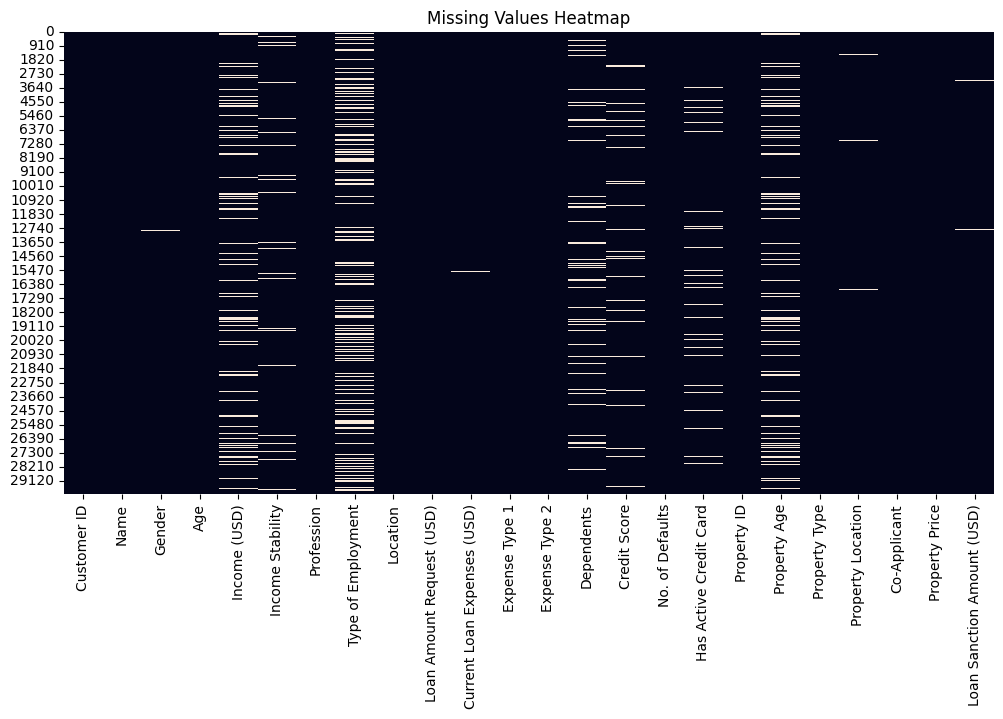

In [ ]:
print("Missing Values")

missing=pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

display(missing[missing["Missing Values"]>0].sort_values("Missing Values", ascending=False))

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [ ]:
drop_columns = [
    "Customer ID",
    "Name",
    "Property ID"
]
df = df.drop(columns=drop_columns)
target = "Loan Sanction Amount (USD)"
df = df.dropna(subset=[target]).reset_index(drop=True)
X = df.drop(columns=target)
y = df[target]
categorical_columns = X.select_dtypes(include=["object"]).columns
numerical_columns = X.select_dtypes(exclude=["object"]).columns
print("Dataset Shape:", df.shape)
print("Categorical Columns")
print(categorical_columns)
print()
print("Numerical Columns")
print(numerical_columns)

Dataset Shape: (29660, 21)
Categorical Columns
Index(['Gender', 'Income Stability', 'Profession', 'Type of Employment',
       'Location', 'Expense Type 1', 'Expense Type 2',
       'Has Active Credit Card', 'Property Location'],
      dtype='object')

Numerical Columns
Index(['Age', 'Income (USD)', 'Loan Amount Request (USD)',
       'Current Loan Expenses (USD)', 'Dependents', 'Credit Score',
       'No. of Defaults', 'Property Age', 'Property Type', 'Co-Applicant',
       'Property Price'],
      dtype='object')


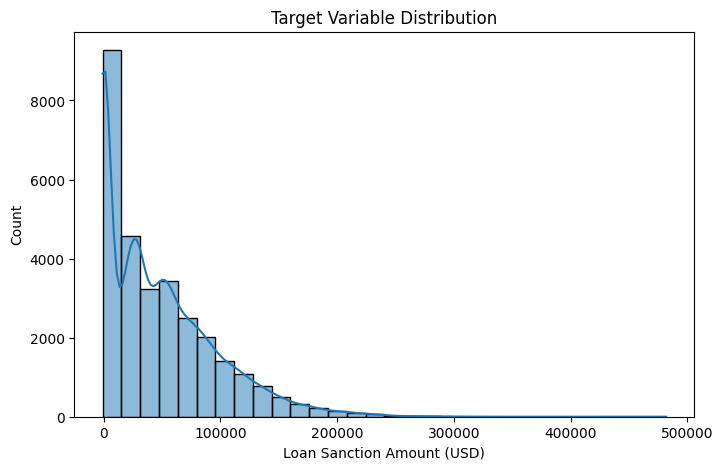

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(y, bins=30, kde=True)
plt.title("Target Variable Distribution")
plt.xlabel("Loan Sanction Amount (USD)")
plt.ylabel("Count")
plt.show()

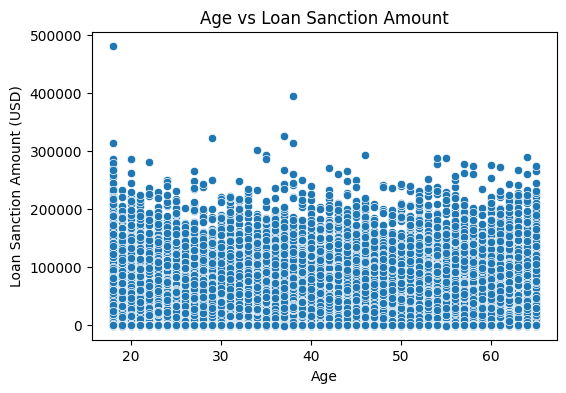

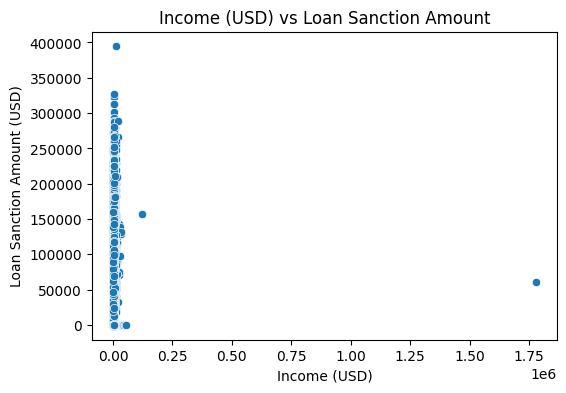

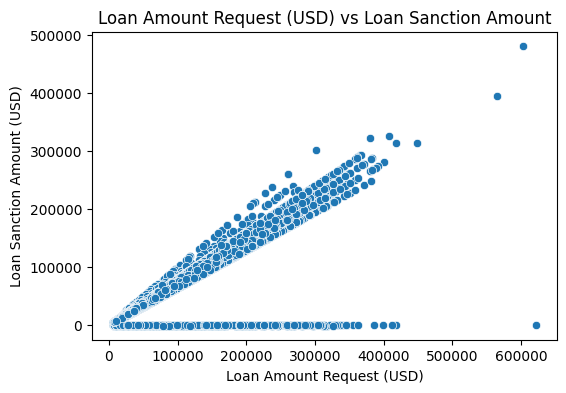

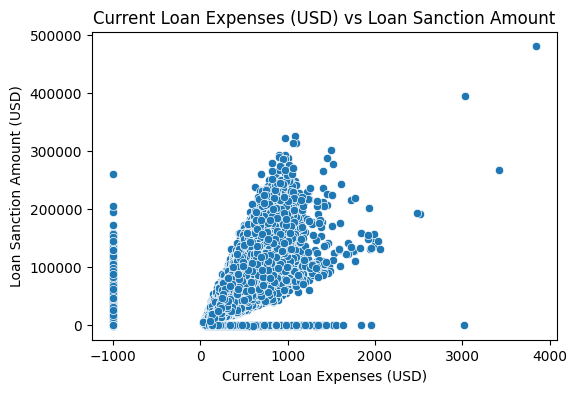

In [ ]:
selected_features=numerical_columns[:4]

for feature in selected_features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[feature], y=y)
    plt.title(f"{feature} vs Loan Sanction Amount")
    plt.show()

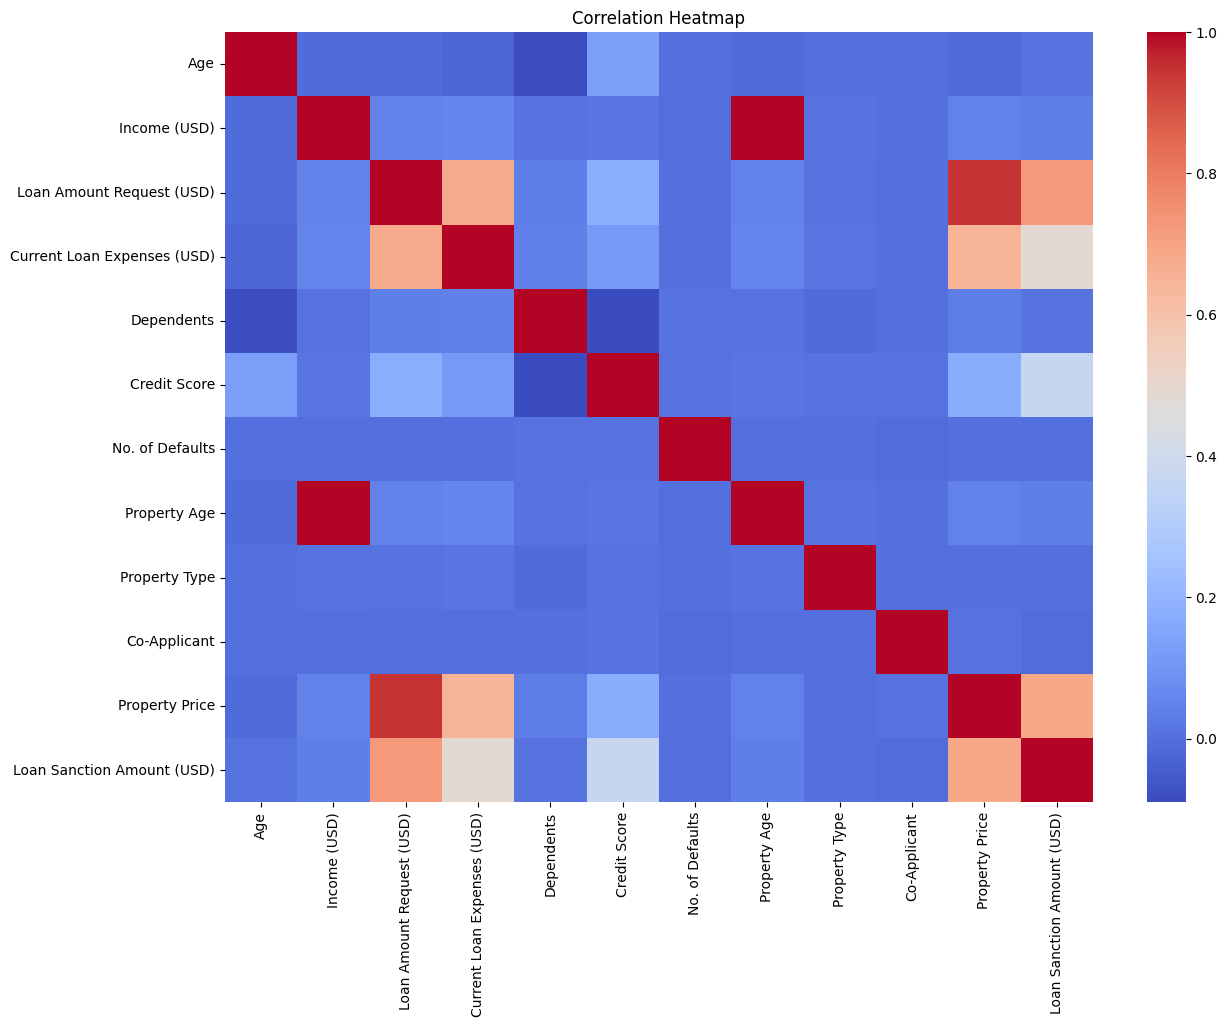

In [ ]:
plt.figure(figsize=(14,10))
corr=df[numerical_columns.tolist() + [target]].corr()
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
numeric_transformer=Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer=Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor=ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_columns),
        ("cat", categorical_transformer, categorical_columns)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (23728, 20)
Testing Shape: (5932, 20)


In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": GridSearchCV(
        Ridge(),
        {"alpha": [0.01, 0.1, 1, 10, 100]},
        cv=5,
        scoring="r2",
        n_jobs=-1
    ),
    "Lasso Regression": GridSearchCV(
        Lasso(max_iter=10000),
        {"alpha": [0.001, 0.01, 0.1, 1, 10]},
        cv=5,
        scoring="r2",
        n_jobs=-1
    ),
    "Elastic Net Regression": GridSearchCV(
        ElasticNet(max_iter=10000),
        {
            "alpha": [0.01, 0.1, 1, 10],
            "l1_ratio": [0.2, 0.5, 0.8]
        },
        cv=5,
        scoring="r2",
        n_jobs=-1
    )
}

In [ ]:
results=[]
cv_results=[]
tuning_results=[]
trained_models={}
predictions={}
training_errors={}
validation_errors={}

In [ ]:
for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    start = time.time()
    pipeline.fit(X_train, y_train)
    end = time.time()
    train_time = end - start
    y_pred = pipeline.predict(X_test)
    predictions[name] = y_pred
    trained_models[name] = pipeline
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    train_pred = pipeline.predict(X_train)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = rmse
    training_errors[name] = train_rmse
    validation_errors[name] = test_rmse
    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "Training Time": train_time
    })
    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=5,
        scoring={
            "mae": "neg_mean_absolute_error",
            "mse": "neg_mean_squared_error",
            "r2": "r2"
        },
        n_jobs=-1
    )
    cv_results.append({
        "Model": name,
        "MAE": -scores["test_mae"].mean(),
        "MSE": -scores["test_mse"].mean(),
        "RMSE": np.sqrt(-scores["test_mse"].mean()),
        "R2": scores["test_r2"].mean()
    })
    if name != "Linear Regression":
        best = pipeline.named_steps["model"]
        tuning_results.append({
            "Model": name,
            "Search Method": "Grid Search",
            "Best Parameters": best.best_params_,
            "Best CV R2": best.best_score_
        })

In [ ]:
test_table = pd.DataFrame(results)
cv_table = pd.DataFrame(cv_results)
tuning_table = pd.DataFrame(tuning_results)
print("Table 1 : Hyperparameter Tuning Summary")
display(tuning_table)
print()
print("Table 2 : Cross Validation Performance")
display(cv_table)
print()
print("Table 3 : Test Set Performance")
display(test_table)

Table 1 : Hyperparameter Tuning Summary


,Model,Search Method,Best Parameters,Best CV R2
0,Ridge Regression,Grid Search,{'alpha': 100},0.574334
1,Lasso Regression,Grid Search,{'alpha': 10},0.570431
2,Elastic Net Regression,Grid Search,"{'alpha': 0.1, 'l1_ratio': 0.5}",0.584412



Table 2 : Cross Validation Performance


,Model,MAE,MSE,RMSE,R2
0,Linear Regression,21590.283756,9.942411e+08,31531.588152,0.572041
1,Ridge Regression,21600.823566,9.938960e+08,31526.116233,0.572185
2,Lasso Regression,21579.308143,9.931601e+08,31514.442959,0.572500
3,Elastic Net Regression,21687.101330,9.958900e+08,31557.725020,0.571312



Table 3 : Test Set Performance


,Model,MAE,MSE,RMSE,R2,Training Time
0,Linear Regression,21589.123325,1.018934e+09,31920.751553,0.551086,0.192784
1,Ridge Regression,21581.576017,1.017251e+09,31894.374343,0.551827,1.030997
2,Lasso Regression,21563.903138,1.017765e+09,31902.431353,0.551601,228.601636
3,Elastic Net Regression,21751.473117,1.018508e+09,31914.065979,0.551274,33.362066


In [ ]:
best_model_name = test_table.sort_values(
    "R2",
    ascending=False
).iloc[0]["Model"]

print("Best Model :", best_model_name)

Best Model : Ridge Regression


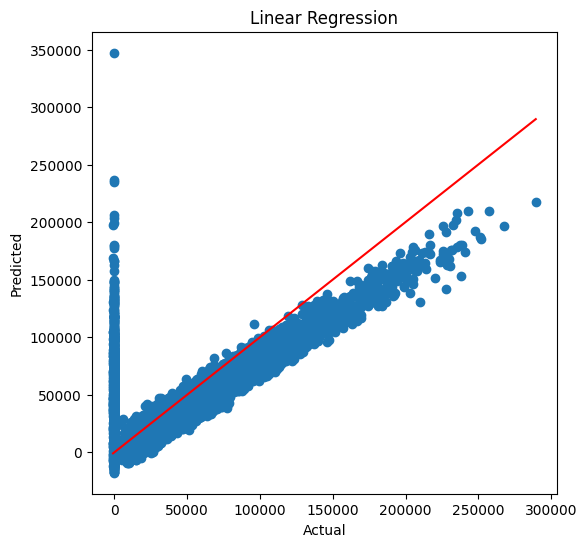

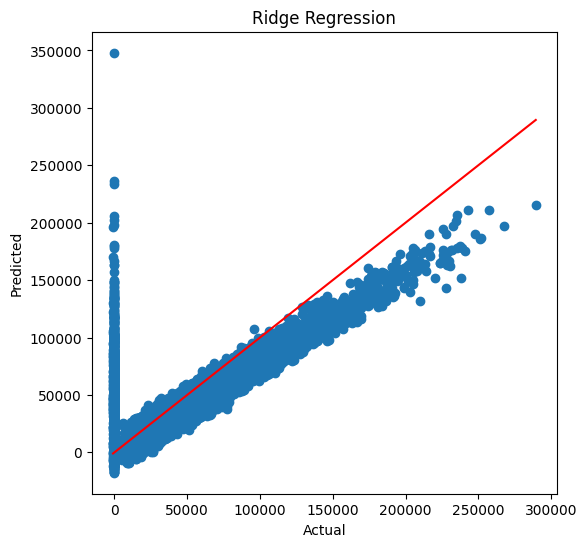

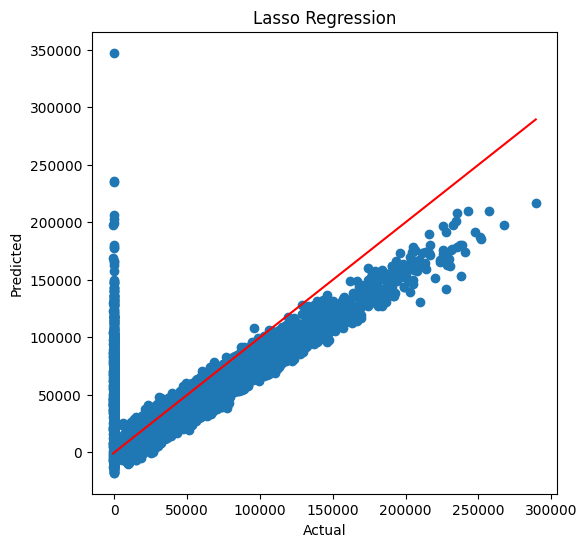

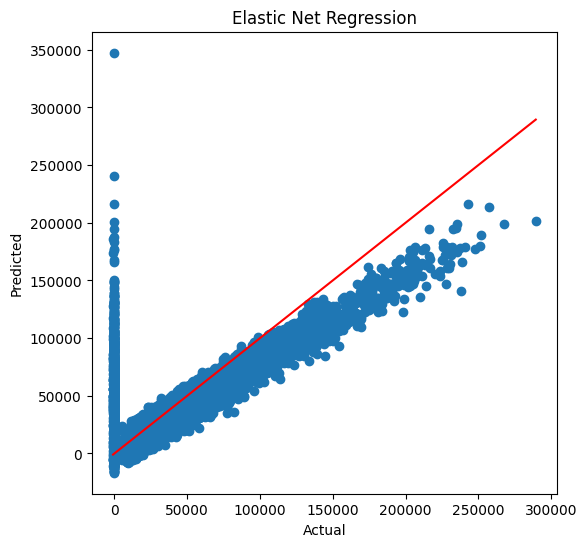

In [ ]:
for model in predictions:
    plt.figure(figsize=(6,6))
    plt.scatter(y_test, predictions[model])
    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color="red"
    )
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(model)
    plt.show()

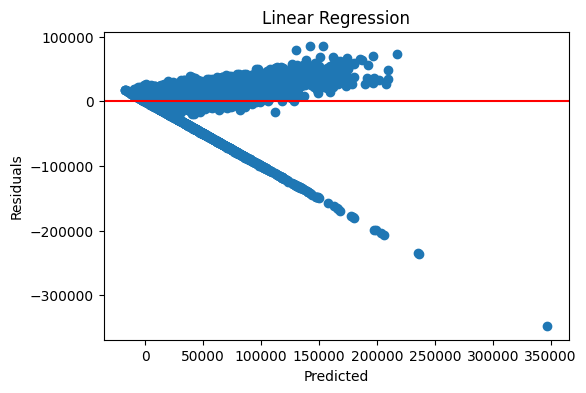

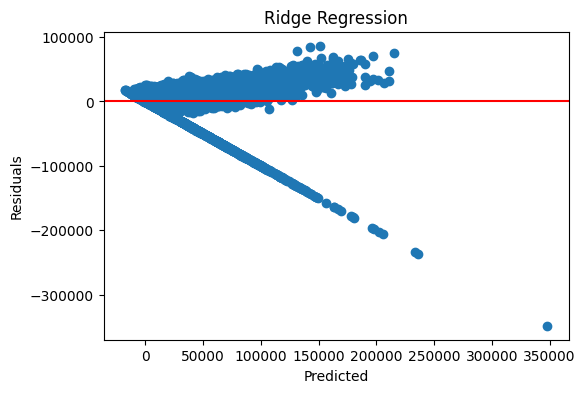

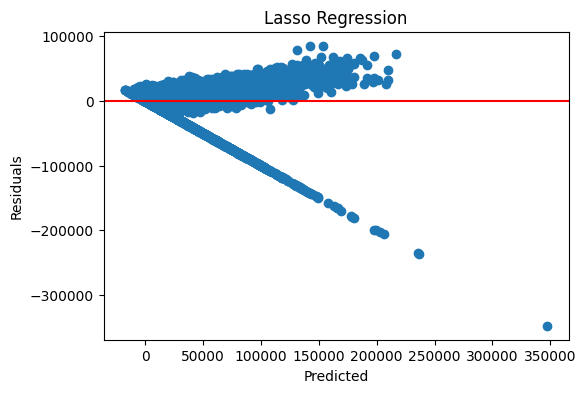

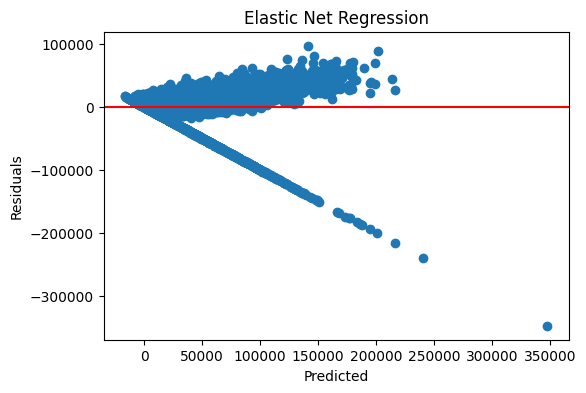

In [ ]:
for model in predictions:
    residuals = y_test - predictions[model]
    plt.figure(figsize=(6,4))
    plt.scatter(predictions[model], residuals)
    plt.axhline(0, color="red")
    plt.xlabel("Predicted")
    plt.ylabel("Residuals")
    plt.title(model)
    plt.show()

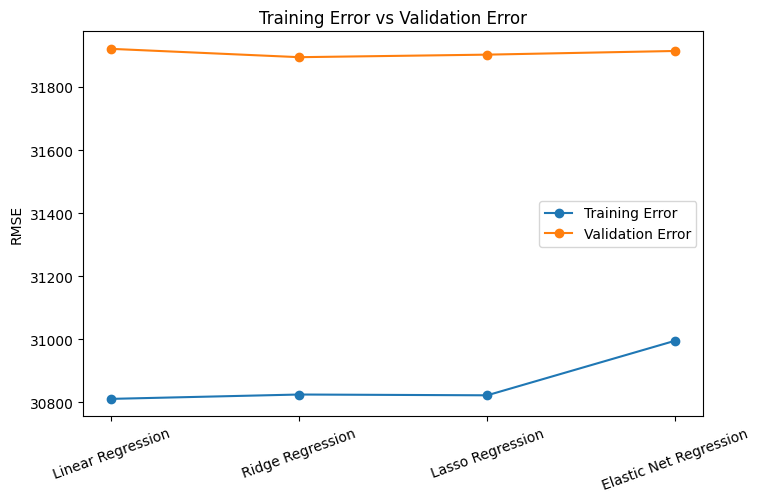

In [ ]:
plt.figure(figsize=(8,5))
model_names = list(training_errors.keys())
train_values = list(training_errors.values())
validation_values = list(validation_errors.values())
x = np.arange(len(model_names))
plt.plot(x, train_values, marker="o", label="Training Error")
plt.plot(x, validation_values, marker="o", label="Validation Error")
plt.xticks(x, model_names, rotation=20)
plt.ylabel("RMSE")
plt.title("Training Error vs Validation Error")
plt.legend()
plt.show()

In [ ]:
feature_names = trained_models["Linear Regression"].named_steps["preprocessor"].get_feature_names_out()
linear_coef = trained_models["Linear Regression"].named_steps["model"].coef_
ridge_coef = trained_models["Ridge Regression"].named_steps["model"].best_estimator_.coef_
lasso_coef = trained_models["Lasso Regression"].named_steps["model"].best_estimator_.coef_
elastic_coef = trained_models["Elastic Net Regression"].named_steps["model"].best_estimator_.coef_

In [ ]:
coefficient_table = pd.DataFrame({
    "Feature": feature_names,
    "Linear": linear_coef,
    "Ridge": ridge_coef,
    "Lasso": lasso_coef,
    "Elastic Net": elastic_coef
})
coefficient_table["Importance"] = np.abs(coefficient_table["Linear"])
coefficient_table = coefficient_table.sort_values(
    "Importance",
    ascending=False
)
coefficient_table = coefficient_table.drop(columns="Importance")
print("Table 4 : Coefficient Comparison")
display(coefficient_table.head(20))

Table 4 : Coefficient Comparison


,Feature,Linear,Ridge,Lasso,Elastic Net
1,num__Income (USD),47689.456738,1040.644690,4.716913e+00,97.873126
7,num__Property Age,-47676.043705,-1031.929523,0.000000e+00,-86.184451
2,num__Loan Amount Request (USD),35370.837982,33830.768537,3.517478e+04,25157.706362
19,cat__Profession_Student,-13233.813700,-125.820277,-0.000000e+00,-8.911429
15,cat__Profession_Businessman,12679.050548,130.803458,0.000000e+00,11.516516
5,num__Credit Score,11636.760990,11621.554175,1.164872e+04,11285.429123
17,cat__Profession_Pensioner,6535.941011,2981.054315,4.431235e+03,286.012609
35,cat__Type of Employment_Realty agents,6333.883545,2423.471532,2.495475e+03,307.414633
29,cat__Type of Employment_IT staff,-5671.093949,-2115.415666,-1.719171e+03,-270.087145
13,cat__Income Stability_High,-4821.076671,-2812.349933,-6.329422e+03,-704.377919


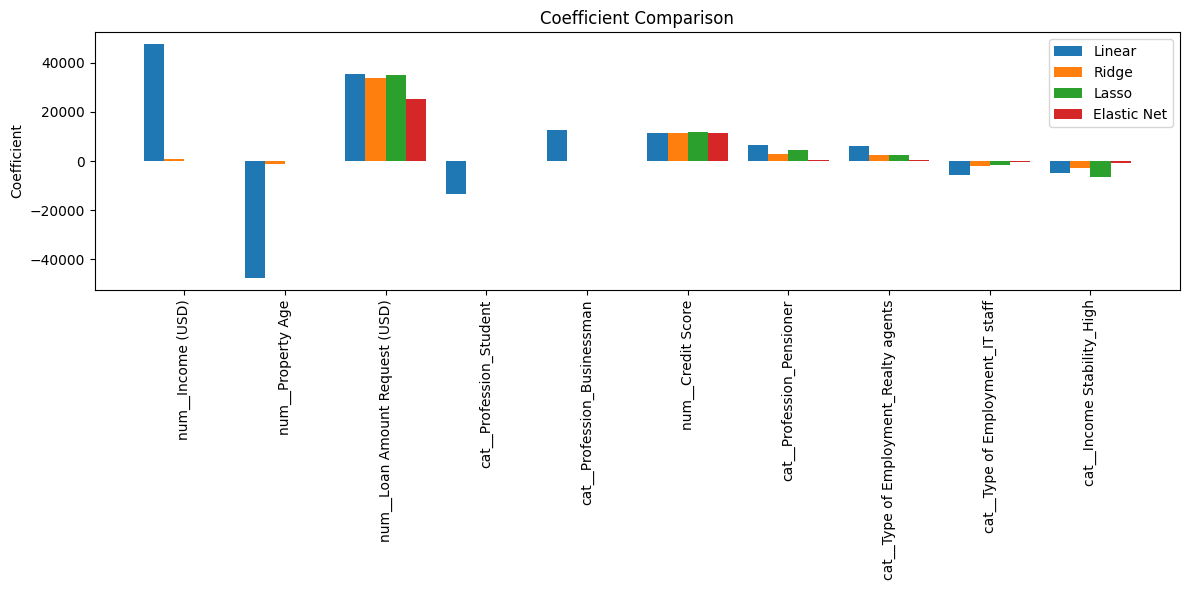

In [ ]:
top = coefficient_table.head(10)
plt.figure(figsize=(12,6))
x = np.arange(len(top))
width = 0.2
plt.bar(x-width*1.5, top["Linear"], width, label="Linear")
plt.bar(x-width/2, top["Ridge"], width, label="Ridge")
plt.bar(x+width/2, top["Lasso"], width, label="Lasso")
plt.bar(x+width*1.5, top["Elastic Net"], width, label="Elastic Net")
plt.xticks(x, top["Feature"], rotation=90)
plt.ylabel("Coefficient")
plt.title("Coefficient Comparison")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
analysis = pd.DataFrame({
    "Model": model_names,
    "Training RMSE": train_values,
    "Validation RMSE": validation_values
})
display(analysis)
print()
for i in range(len(analysis)):
    train_error = analysis.loc[i, "Training RMSE"]
    validation_error = analysis.loc[i, "Validation RMSE"]
    difference = abs(train_error - validation_error)
    print(analysis.loc[i, "Model"])
    if difference < 500:
        print("Generalizes well")
    elif train_error < validation_error:
        print("Possible Overfitting")
    else:
        print("Possible Underfitting")
    print()

,Model,Training RMSE,Validation RMSE
0,Linear Regression,30811.104103,31920.751553
1,Ridge Regression,30824.900599,31894.374343
2,Lasso Regression,30822.394710,31902.431353
3,Elastic Net Regression,30995.380930,31914.065979



Linear Regression
Possible Overfitting

Ridge Regression
Possible Overfitting

Lasso Regression
Possible Overfitting

Elastic Net Regression
Possible Overfitting



In [ ]:
best = test_table.sort_values("R2", ascending=False).iloc[0]

print("Best Performing Model")
display(best.to_frame().T)

print()

Best Performing Model


,Model,MAE,MSE,RMSE,R2,Training Time
1,Ridge Regression,21581.576017,1017251114.752553,31894.374343,0.551827,1.030997
